Part III: Building a CNN

1. Load, preprocess, analyze, visualize the dataset and make it ready for training.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
zip_path = "/content/datasets.zip"
extract_path = "/content/datasets"

!unzip -q "{zip_path}" -d "{extract_path}"

print("Unzipped files saved to:", extract_path)
!ls -la "{extract_path}"

Unzipped files saved to: /content/datasets
total 49240
drwxr-xr-x 2 root root     4096 Nov  7 03:46 .
drwxr-xr-x 1 root root     4096 Nov  7 03:46 ..
-rw-r--r-- 1 root root 50387523 Oct 13  2023 cnn_dataset.zip
-rw-r--r-- 1 root root    21438 Oct 12  2023 dataset.csv


In [ ]:
zip_path = "/content/datasets/cnn_dataset.zip"
extract_path = "/content/datasets/cnn_dataset"

!unzip -q "{zip_path}" -d "{extract_path}"

print("Unzipped files saved to:", extract_path)
!ls -la "{extract_path}"

Unzipped files saved to: /content/datasets/cnn_dataset
total 12
drwxr-xr-x  3 root root 4096 Nov  7 03:46 .
drwxr-xr-x  3 root root 4096 Nov  7 03:46 ..
drwxr-xr-x 38 root root 4096 Nov  7 03:46 cnn_dataset


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root="/content/datasets/cnn_dataset/cnn_dataset", transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4)
print("Total images:", len(dataset))
print("Number of classes:", len(dataset.classes))
print("Class names:", dataset.classes)


Total images: 100800
Number of classes: 36
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


0: 2800 images
1: 2800 images
2: 2800 images
3: 2800 images
4: 2800 images
5: 2800 images
6: 2800 images
7: 2800 images
8: 2800 images
9: 2800 images
A: 2800 images
B: 2800 images
C: 2800 images
D: 2800 images
E: 2800 images
F: 2800 images
G: 2800 images
H: 2800 images
I: 2800 images
J: 2800 images
K: 2800 images
L: 2800 images
M: 2800 images
N: 2800 images
O: 2800 images
P: 2800 images
Q: 2800 images
R: 2800 images
S: 2800 images
T: 2800 images
U: 2800 images
V: 2800 images
W: 2800 images
X: 2800 images
Y: 2800 images
Z: 2800 images


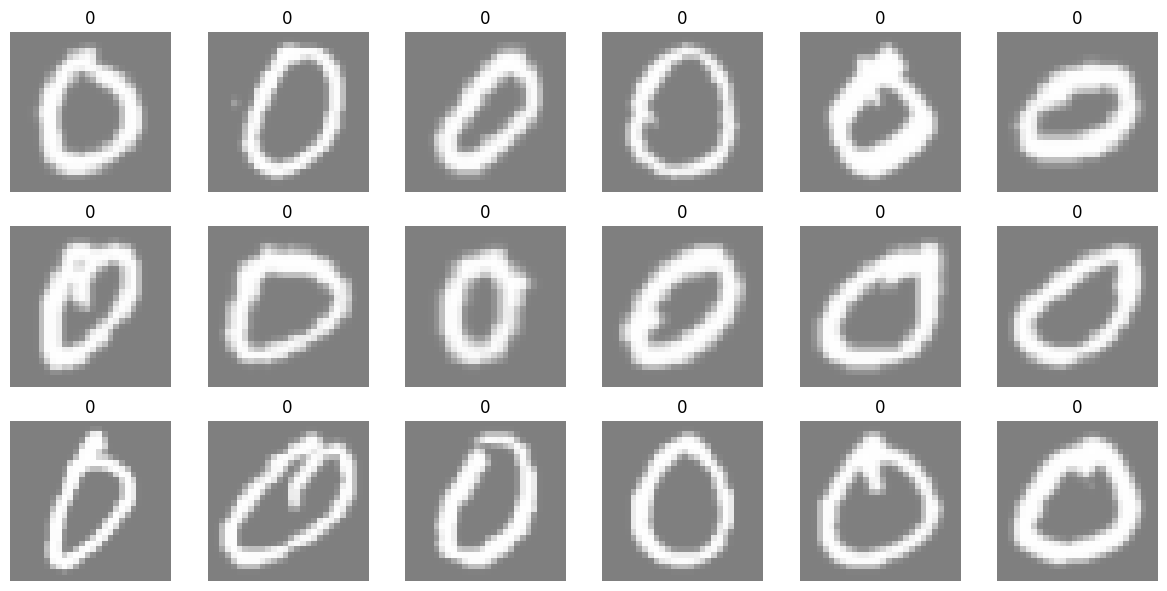

Pixel value range: 0.0 to 1.0
Mean per channel: tensor([0.1758, 0.1758, 0.1758])
Std per channel: tensor([0.3337, 0.3337, 0.3337])


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter


targets = [label for _, label in dataset]
class_counts = Counter(targets)
for i, cls in enumerate(dataset.classes):
    print(f"{cls}: {class_counts[i]} images")


fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, (img, label) in zip(axes.flatten(), dataset):
    img = img.permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5
    ax.imshow(img)
    ax.set_title(dataset.classes[label])
    ax.axis('off')
plt.tight_layout()
plt.show()


all_pixels = torch.stack([img for img, _ in dataset])
print("Pixel value range:", all_pixels.min().item(), "to", all_pixels.max().item())
print("Mean per channel:", all_pixels.mean(dim=(0,2,3)))
print("Std per channel:", all_pixels.std(dim=(0,2,3)))


In [ ]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


2. Build and train a basic CNN and 3. Defining Parameters

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(dataset.classes)

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128*7*7, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)


        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

model = CNNModel()
print(model)


CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6272, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=36, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


The CNN takes RGB images of size 28×28, so the input has 3 channels. The output has as many neurons as classes in your dataset. Hidden layers use ReLU activation, and the output layer uses no activation because CrossEntropyLoss applies softmax. There are 6 hidden layers: 4 convolutional layers (32, 64, 128, 128 filters) and 2 fully connected layers (512 and 256 neurons). Dropout with p=0.3 is included after the fully connected layers.

4. Summary of Model

In [ ]:
!pip install torchinfo
from torchinfo import summary
model = CNNModel()
summary(model, input_size=(64, 3, 28, 28))


Layer (type:depth-idx)                   Output Shape              Param #
CNNModel                                 [64, 36]                  --
├─Conv2d: 1-1                            [64, 32, 28, 28]          896
├─Conv2d: 1-2                            [64, 64, 28, 28]          18,496
├─MaxPool2d: 1-3                         [64, 64, 14, 14]          --
├─Conv2d: 1-4                            [64, 128, 14, 14]         73,856
├─Conv2d: 1-5                            [64, 128, 14, 14]         147,584
├─MaxPool2d: 1-6                         [64, 128, 7, 7]           --
├─Linear: 1-7                            [64, 512]                 3,211,776
├─Dropout: 1-8                           [64, 512]                 --
├─Linear: 1-9                            [64, 256]                 131,328
├─Dropout: 1-10                          [64, 256]                 --
├─Linear: 1-11                           [64, 36]                  9,252
Total params: 3,593,188
Trainable params: 3,593,188
Non-

In [ ]:
from torch.utils.data import random_split, DataLoader
from torchvision import datasets

dataset = datasets.ImageFolder(root='/content/datasets/cnn_dataset/cnn_dataset', transform=transform)


train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 70560
Validation samples: 20160
Test samples: 10080


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Using device: cuda
Epoch [1/20] | Train Loss: 0.6733 | Val Loss: 0.3465 | Train Acc: 0.7827 | Val Acc: 0.8773
Epoch [2/20] | Train Loss: 0.3325 | Val Loss: 0.2844 | Train Acc: 0.8806 | Val Acc: 0.8968
Epoch [3/20] | Train Loss: 0.2871 | Val Loss: 0.2588 | Train Acc: 0.8947 | Val Acc: 0.9033
Epoch [4/20] | Train Loss: 0.2578 | Val Loss: 0.2590 | Train Acc: 0.9024 | Val Acc: 0.9062
Epoch [5/20] | Train Loss: 0.2366 | Val Loss: 0.2568 | Train Acc: 0.9097 | Val Acc: 0.9091
Epoch [6/20] | Train Loss: 0.2251 | Val Loss: 0.2482 | Train Acc: 0.9131 | Val Acc: 0.9088
Epoch [7/20] | Train Loss: 0.2079 | Val Loss: 0.2472 | Train Acc: 0.9190 | Val Acc: 0.9084
Epoch [8/20] | Train Loss: 0.2012 | Val Loss: 0.2594 | Train Acc: 0.9202 | Val Acc: 0.9059
Epoch [9/20] | Train Loss: 0.1919 | Val Loss: 0.2644 | Train Acc: 0.9224 | Val Acc: 0.9095
Epoch [10/20] | Train Loss: 0.1856 | Val Loss: 0.2586 | Train Acc: 0.9247 | Val Acc: 0.9074
Epoch [11/20] | Train Loss: 0.1812 | Val Loss: 0.2750 | Train Acc: 0.9

1. Early Stopping Optimizer

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

patience = 5
best_val_loss = np.inf
counter = 0
num_epochs = 20

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to('cuda'), labels.to('cuda')

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch [1/20] | Train Loss: 0.1373 | Val Loss: 0.3197 | Train Acc: 0.9427 | Val Acc: 0.9132
Epoch [2/20] | Train Loss: 0.1291 | Val Loss: 0.3215 | Train Acc: 0.9449 | Val Acc: 0.9125
Epoch [3/20] | Train Loss: 0.1267 | Val Loss: 0.3400 | Train Acc: 0.9463 | Val Acc: 0.9125
Epoch [4/20] | Train Loss: 0.1264 | Val Loss: 0.3395 | Train Acc: 0.9461 | Val Acc: 0.9124
Epoch [5/20] | Train Loss: 0.1227 | Val Loss: 0.3374 | Train Acc: 0.9486 | Val Acc: 0.9121
Epoch [6/20] | Train Loss: 0.1195 | Val Loss: 0.3432 | Train Acc: 0.9490 | Val Acc: 0.9123
Early stopping triggered.


2. Gradient Accumulation Optimizer

In [ ]:
num_epochs = 10
accumulation_steps = 4
train_losses, val_losses = [], []

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels) / accumulation_steps
        loss.backward()
        running_loss += loss.item() * accumulation_steps

        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

    train_losses.append(running_loss / len(train_loader))


    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_losses.append(val_loss / len(val_loader))
    val_acc = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")


Epoch [1/10] | Train Loss: 0.1070 | Val Loss: 0.3824 | Val Acc: 0.9140
Epoch [2/10] | Train Loss: 0.0964 | Val Loss: 0.3913 | Val Acc: 0.9146
Epoch [3/10] | Train Loss: 0.0928 | Val Loss: 0.4176 | Val Acc: 0.9157
Epoch [4/10] | Train Loss: 0.0922 | Val Loss: 0.4052 | Val Acc: 0.9130
Epoch [5/10] | Train Loss: 0.0876 | Val Loss: 0.4127 | Val Acc: 0.9136
Epoch [6/10] | Train Loss: 0.0850 | Val Loss: 0.4311 | Val Acc: 0.9148
Epoch [7/10] | Train Loss: 0.0843 | Val Loss: 0.4224 | Val Acc: 0.9157
Epoch [8/10] | Train Loss: 0.0819 | Val Loss: 0.4591 | Val Acc: 0.9148
Epoch [9/10] | Train Loss: 0.0793 | Val Loss: 0.4565 | Val Acc: 0.9124
Epoch [10/10] | Train Loss: 0.0768 | Val Loss: 0.4515 | Val Acc: 0.9142


3. Learning Rate Scheduler Optimizer

In [ ]:
num_epochs = 10
train_losses, val_losses = [], []

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)  # reduce LR by 0.5 every 3 epochs

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))


    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_acc = correct / total

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")


Epoch [1/10] | Train Loss: 0.0992 | Val Loss: 0.4508 | Val Acc: 0.9108 | LR: 0.001000
Epoch [2/10] | Train Loss: 0.1006 | Val Loss: 0.4426 | Val Acc: 0.9122 | LR: 0.001000
Epoch [3/10] | Train Loss: 0.1009 | Val Loss: 0.4502 | Val Acc: 0.9100 | LR: 0.000500
Epoch [4/10] | Train Loss: 0.0819 | Val Loss: 0.4433 | Val Acc: 0.9147 | LR: 0.000500
Epoch [5/10] | Train Loss: 0.0732 | Val Loss: 0.4884 | Val Acc: 0.9129 | LR: 0.000500
Epoch [6/10] | Train Loss: 0.0711 | Val Loss: 0.4999 | Val Acc: 0.9121 | LR: 0.000250
Epoch [7/10] | Train Loss: 0.0600 | Val Loss: 0.5580 | Val Acc: 0.9131 | LR: 0.000250
Epoch [8/10] | Train Loss: 0.0577 | Val Loss: 0.5548 | Val Acc: 0.9139 | LR: 0.000250
Epoch [9/10] | Train Loss: 0.0543 | Val Loss: 0.5777 | Val Acc: 0.9134 | LR: 0.000125
Epoch [10/10] | Train Loss: 0.0492 | Val Loss: 0.5973 | Val Acc: 0.9133 | LR: 0.000125


In [ ]:
import torch

torch.save(model.state_dict(), "/content/best_cnn_early_stopping.pth")
print("Model weights saved successfully.")


Model weights saved successfully.


Evaluate model on testing data

In [ ]:
import torch
import time
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


model.to(device)
model.eval()

start_time = time.time()

all_preds = []
all_labels = []
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end_time = time.time()


test_loss_value = test_loss / len(test_loader)


accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

print(f"Time to evaluate: {end_time - start_time:.2f} seconds")
print(f"Test Loss: {test_loss_value:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Time to evaluate: 4.27 seconds
Test Loss: 0.6136
Test Accuracy: 0.9142
Precision: 0.9148
Recall: 0.9142
F1 Score: 0.9141


Visualizations

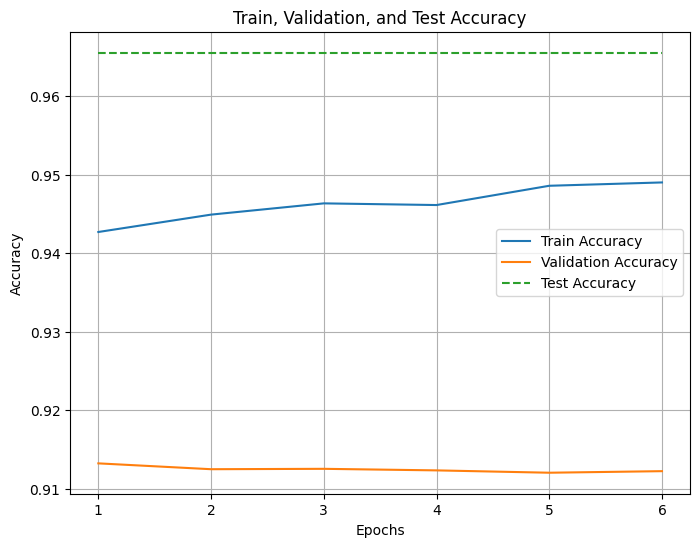

In [ ]:
import matplotlib.pyplot as plt


num_epochs = len(train_accuracies)

test_accuracy_value = 0.9655
test_acc_line = [test_accuracy_value] * num_epochs

plt.figure(figsize=(8,6))
plt.plot(range(1, num_epochs+1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Validation Accuracy')
plt.plot(range(1, num_epochs+1), test_acc_line, label='Test Accuracy', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train, Validation, and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()


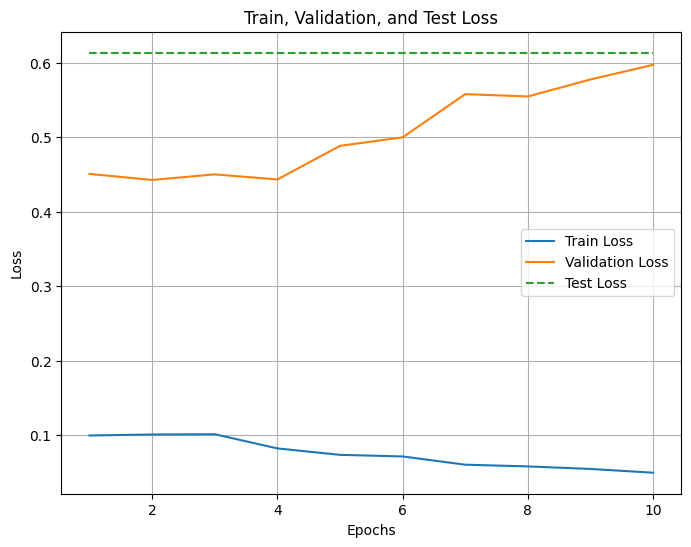

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses)+1)
test_loss_line = [test_loss_value] * len(train_losses)

plt.figure(figsize=(8,6))
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.plot(epochs_range, test_loss_line, label='Test Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train, Validation, and Test Loss')
plt.legend()
plt.grid(True)
plt.show()


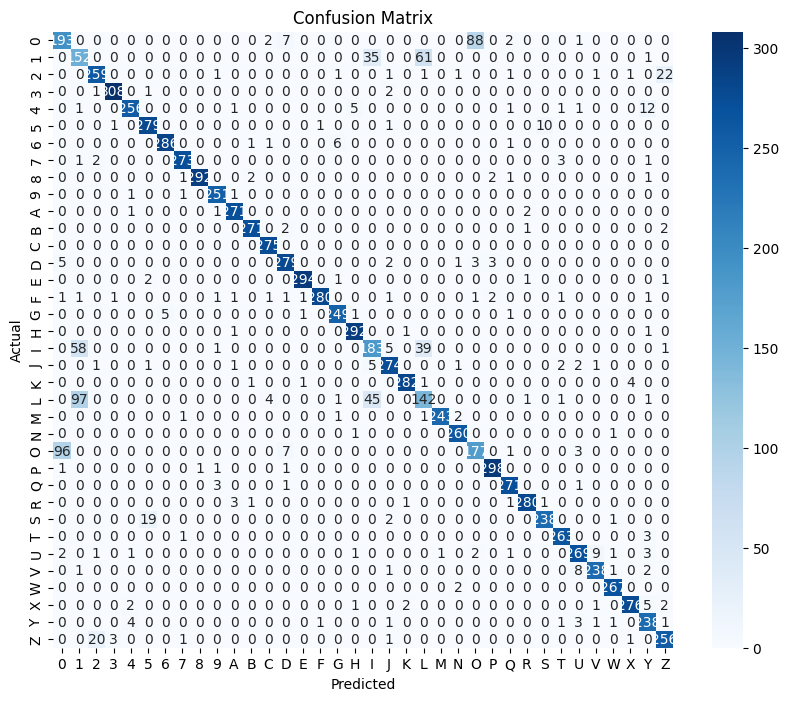

In [ ]:
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


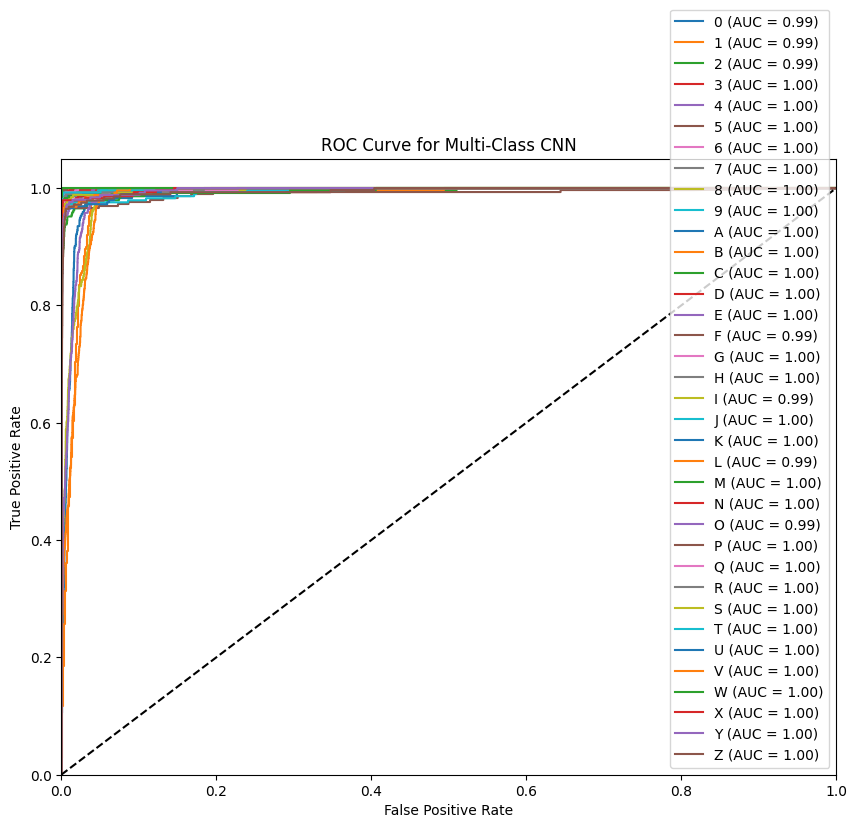

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np


y_test = label_binarize(all_labels, classes=range(len(dataset.classes)))
y_score = []

model.eval()
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        outputs = torch.softmax(outputs, dim=1)
        y_score.append(outputs.cpu().numpy())
y_score = np.vstack(y_score)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(dataset.classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10,8))
for i in range(len(dataset.classes)):
    plt.plot(fpr[i], tpr[i], label=f'{dataset.classes[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class CNN')
plt.legend(loc='lower right')
plt.show()


Part IV: VGG-13 Implementation

In [ ]:
import torch
import torch.nn as nn


_cfgs = {
    'B': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
}

def make_layers(cfg, in_channels=3, batch_norm=False):
    layers = []
    C = in_channels
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(C, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            C = v
    return nn.Sequential(*layers)

class VGG(nn.Module):
    def __init__(self, cfg_key='B', in_channels=3, num_classes=36, batch_norm=True, dropout_p=0.5):
        super().__init__()
        assert cfg_key in _cfgs, f"Unknown cfg {cfg_key}"
        self.features = make_layers(_cfgs[cfg_key], in_channels=in_channels, batch_norm=batch_norm)

        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout_p),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(p=dropout_p),
            nn.Linear(4096, num_classes),
        )


        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)


num_classes = len(dataset.classes)
model = VGG(cfg_key='B', in_channels=3, num_classes=num_classes, batch_norm=True, dropout_p=0.5).to(device)
print(model)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [ ]:
import torch
import torch.nn as nn

class VGG13Custom(nn.Module):
    def __init__(self, num_classes=36):
        super(VGG13Custom, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),


            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),


            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

        )


        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))


        self.classifier = nn.Sequential(
            nn.Linear(256*2*2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x



model_vgg = VGG13Custom(num_classes=36)
print(model_vgg)


VGG13Custom(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vgg = model_vgg.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_vgg.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)



In [ ]:
num_epochs = 30
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model_vgg.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_vgg(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    model_vgg.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_vgg(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)


    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Epoch [1/30] | Train Loss: 0.9220 | Val Loss: 0.3892 | Train Acc: 0.7045 | Val Acc: 0.8566
Epoch [2/30] | Train Loss: 0.3375 | Val Loss: 0.2799 | Train Acc: 0.8782 | Val Acc: 0.8961
Epoch [3/30] | Train Loss: 0.2906 | Val Loss: 0.2579 | Train Acc: 0.8945 | Val Acc: 0.9012
Epoch [4/30] | Train Loss: 0.2645 | Val Loss: 0.2389 | Train Acc: 0.9010 | Val Acc: 0.9101
Epoch [5/30] | Train Loss: 0.2487 | Val Loss: 0.2301 | Train Acc: 0.9076 | Val Acc: 0.9134
Epoch [6/30] | Train Loss: 0.2381 | Val Loss: 0.2215 | Train Acc: 0.9102 | Val Acc: 0.9166
Epoch [7/30] | Train Loss: 0.2261 | Val Loss: 0.2428 | Train Acc: 0.9130 | Val Acc: 0.9075
Epoch [8/30] | Train Loss: 0.2215 | Val Loss: 0.2334 | Train Acc: 0.9155 | Val Acc: 0.9126
Epoch [9/30] | Train Loss: 0.2120 | Val Loss: 0.2532 | Train Acc: 0.9186 | Val Acc: 0.9077
Epoch [10/30] | Train Loss: 0.2086 | Val Loss: 0.2170 | Train Acc: 0.9200 | Val Acc: 0.9156
Epoch [11/30] | Train Loss: 0.1707 | Val Loss: 0.1960 | Train Acc: 0.9325 | Val Acc: 0.92

In [ ]:
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")


Training samples: 70560
Validation samples: 20160
Test samples: 10080


In [ ]:
import torch
import time
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


model_vgg.to(device)
model_vgg.eval()

start_time = time.time()

all_preds = []
all_labels = []
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vgg(inputs)


        loss = criterion(outputs, labels)
        test_loss += loss.item()


        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

end_time = time.time()


test_loss /= len(test_loader)


accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

print(f"Time to evaluate: {end_time - start_time:.2f} seconds")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Time to evaluate: 4.49 seconds
Test Loss: 0.2048
Test Accuracy: 0.9265
Precision: 0.9294
Recall: 0.9265
F1 Score: 0.9261


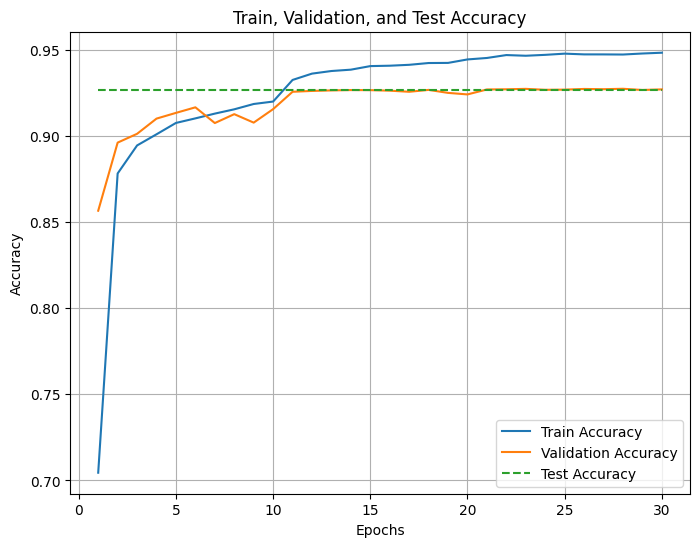

In [ ]:
import matplotlib.pyplot as plt


num_epochs = len(train_accuracies)


test_acc_line = [accuracy] * num_epochs

plt.figure(figsize=(8,6))
plt.plot(range(1, num_epochs+1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Validation Accuracy')
plt.plot(range(1, num_epochs+1), test_acc_line, label='Test Accuracy', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train, Validation, and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()


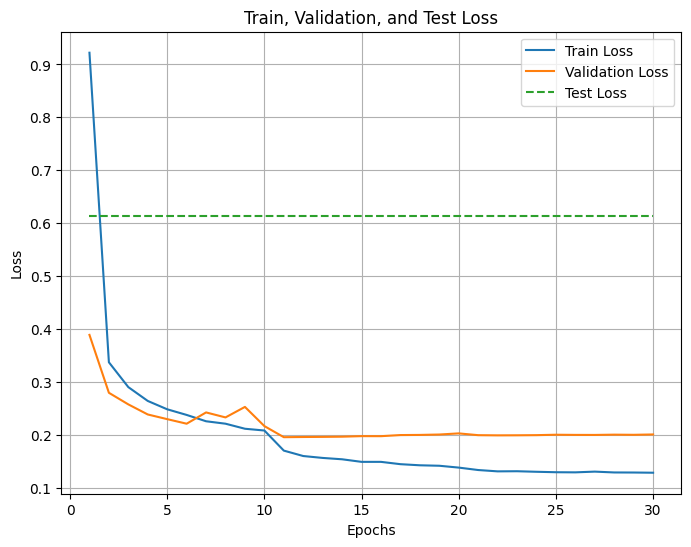

In [ ]:

test_loss_line = [test_loss_value] * len(train_losses)

plt.figure(figsize=(8,6))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.plot(range(1, num_epochs+1), test_loss_line, label='Test Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train, Validation, and Test Loss')
plt.legend()
plt.grid(True)
plt.show()


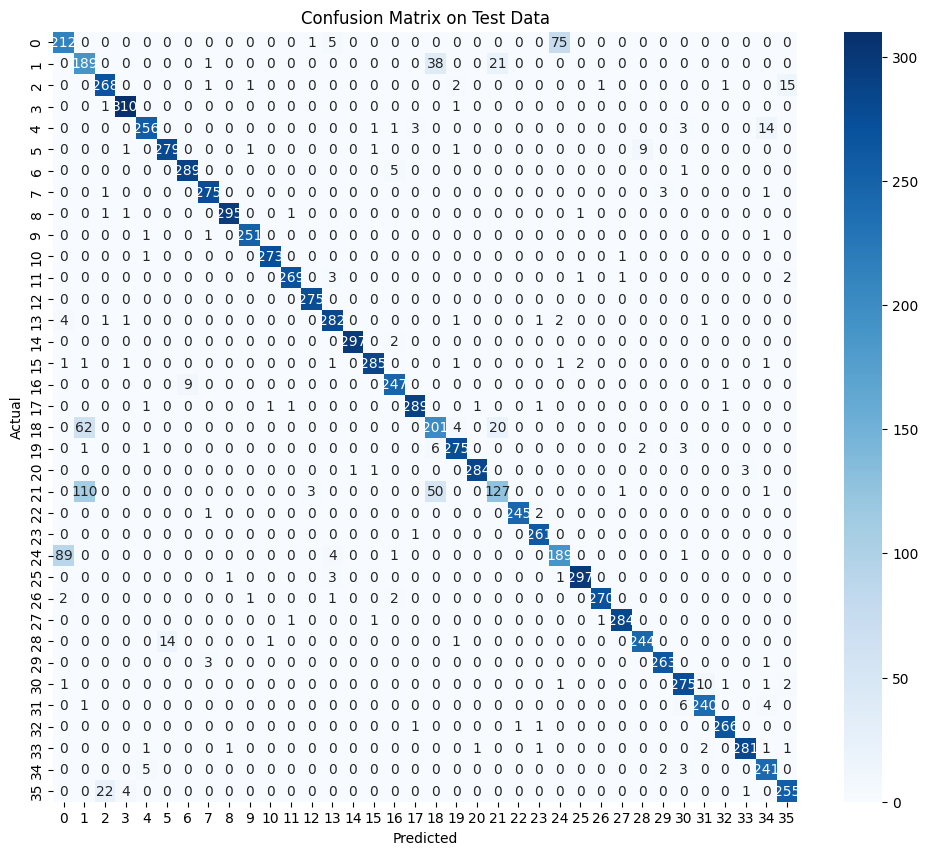

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on Test Data')
plt.show()


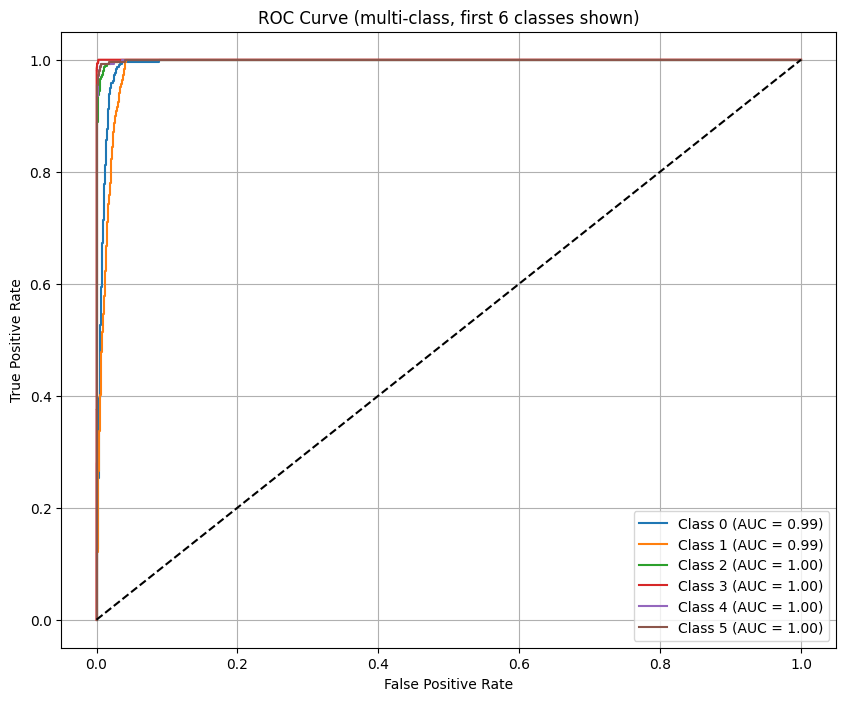

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np


model_vgg.eval()

all_logits = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vgg(inputs)
        all_logits.append(outputs.cpu())
        all_labels.append(labels.cpu())

all_logits = torch.cat(all_logits, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()


n_classes = 36
y_test_binarized = label_binarize(all_labels, classes=list(range(n_classes)))


probs = torch.softmax(torch.tensor(all_logits), dim=1).numpy()

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
for i in range(min(6, n_classes)):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (multi-class, first 6 classes shown)')
plt.legend()
plt.grid(True)
plt.show()
